# CS156 Pipeline - First Draft

In [9]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn import metrics, naive_bayes
from sklearn.feature_extraction import text as t
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


import re
import json
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, Iterable, List, Optional

from __future__ import annotations


sns.set_style("darkgrid")

## Data Overview

As a person who does not go out or take photos that much, I spent sometime thinking about a good data source that is large enough to provide useful insights in this assignment, and I found that the most abundant form of data I have is chats. I particularly focused on the Telegram messeges with my roommates - Alhassan Ahmed, Mohamed Abdelrazik (Wanis), and Alaa Oraby. It was interesting to find out that they are the most people I talk to even though we live together, but the messages also account for our communications over the summer, when we are in different places. Although all of them speak Arabic and come from Egypt and relativily the same culture, I think each of my roommates have a remarkably different personalities that are reflected in how they communicate, which I am trying to explore in this assignment. 

Note: I discussed the idea with three of them, and everyone consented that I could use their messages, and they were excited to see the model's results. 

Fortunately, I was able to export these chats using the Telegram Export feature. The data comes in a JSON format with the following structure:

In [10]:
{
    "id": int,
    "type": "message",
    "date": datetime,
    "date_unixtime": int,
    "from": str,
    "from_id": str,
    "text": str,
    "text_entities": [
        {
        "type": str,
        "text": str
        }
    ]
}

{'id': int,
 'type': 'message',
 'date': datetime.datetime,
 'date_unixtime': int,
 'from': str,
 'from_id': str,
 'text': str,
 'text_entities': [{'type': str, 'text': str}]}

## Loading and Cleaning the Data

While the data structure above is pretty straightforward, it is nested inside a list that is a value for a key called "List" that contains all the messages. To properly work with the data, we first flatten this nested JSON structure and use the keys of the final dictionary as columns for the pandas data frame, in which we store all the messages. 
By examining the JSON file, we see that some messages have extra keys for media, files, and reactions, so we filter these out to keep on text messages. 

After we have the text messages, we do two forms of cleaning
1. Links: some of the messages have 'text_entities' : [{'type': 'link'}], meaning that it only contains a link with no other text. However, links are not written by the sender, so they are not representative of their voices. Therefore, we filter for only messages that have 'text_entities' : [{'type': 'plain'}] to ensure pure text. We do so using  is_text_only_message(), which removes links, files, and media. 

2. Emojis: a decent amount of the messages have texts + emojis, so we remove the emojis given their unicodes as in remove_emojis(). 

In [11]:
# Defining the data source
RESULT_JSON = Path("result.json")

# Display options
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 10)

print("Using file:", RESULT_JSON)
assert RESULT_JSON.exists(), f"JSON file not found: {RESULT_JSON}"

Using file: result.json


### Helper Functions for Data Cleaning and Loading

In [12]:
def remove_emojis(text: str) -> str:
    """Remove emojis and other Unicode symbols from text."""
    if not text:
        return text
    
    # Pattern to match emojis and other Unicode symbols
    # This covers most emoji ranges and symbols
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"  # dingbats
        "\U000024C2-\U0001F251"  # enclosed characters
        "\U0001F900-\U0001F9FF"  # supplemental symbols
        "\U0001FA70-\U0001FAFF"  # symbols and pictographs extended-A
        "\U00002600-\U000026FF"  # miscellaneous symbols
        "\U00002700-\U000027BF"  # dingbats
        "]+", 
        flags=re.UNICODE
    )
    
    return emoji_pattern.sub('', text).strip() 

def _coerce_text(text_field: Any) -> str:
    """Telegram exports sometimes store text as a string or as a list of entities.
    This function returns a simple concatenated plain-text string with emojis removed.
    """
    if text_field is None:
        return ""
    if isinstance(text_field, str):
        return remove_emojis(text_field)
    if isinstance(text_field, list):
        parts: List[str] = []
        for item in text_field:
            # entity may be {"type": "bold", "text": "..."} or {"type": "link", "text": "...", "href": "..."}
            text_val = item.get("text") if isinstance(item, dict) else None
            if isinstance(text_val, str):
                parts.append(text_val)
        combined_text = "".join(parts)
        return remove_emojis(combined_text)
    # fallback
    return remove_emojis(str(text_field))


def _parse_datetime(dt_str: Optional[str]) -> Optional[pd.Timestamp]:
    if not dt_str:
        return None
    try:
        # Telegram uses ISO-like format with timezone, e.g. "2024-01-03T09:02:00"
        return pd.to_datetime(dt_str, utc=True, errors="coerce")
    except Exception:
        return None


def is_text_only_message(msg: Dict[str, Any]) -> bool:
    """Filter to keep only pure text messages, excluding links, files, and voice messages."""
    # Check if message has files or voice
    if msg.get("file") or msg.get("media_type") == "voice_message" or msg.get("duration_seconds"):
        return False
    
    # Check text_raw for link entities
    text_raw = msg.get("text")
    if isinstance(text_raw, list):
        for item in text_raw:
            if isinstance(item, dict) and item.get("type") == "link":
                return False
            # Also check for other non-text entities
            if isinstance(item, dict) and item.get("type") not in ["text", "bold", "italic", "code", "pre"]:
                return False
    
    return True


def normalize_message(msg: Dict[str, Any], chat_title: Optional[str] = None, chat_id: Optional[str] = None) -> Dict[str, Any]:
    """Flatten a single Telegram message dict into a row-friendly mapping."""
    message_id = msg.get("id")
    message_type = msg.get("type") 

    # sender info
    from_id = msg.get("from_id")
    from_name = msg.get("from")

    # date/time
    date_str = msg.get("date")
    date_ts = _parse_datetime(date_str) if isinstance(date_str, str) \
        else pd.to_datetime(int(date_str), unit="s", utc=True, errors="coerce") if date_str is not None else None

    # text
    text_raw = msg.get("text")
    # apply text cleaning
    text_plain = _coerce_text(text_raw)

    # media
    media_type = msg.get("media_type")
    file = msg.get("file")
    photo = msg.get("photo")
    mime_type = msg.get("mime_type")
    duration_seconds = msg.get("duration_seconds")

    # reactions (newer exports)
    reactions = None
    r = msg.get("reactions")
    if isinstance(r, dict):
        # Could be {"results": [{"reaction": "👍", "count": 2}, ...]}
        results = r.get("results")
        if isinstance(results, list):
            reactions = {str(item.get("reaction")): item.get("count") for item in results if isinstance(item, dict)}

    # forward info
    forward_from = None
    if isinstance(msg.get("forwarded_from"), dict):
        fwd = msg["forwarded_from"]
        forward_from = fwd.get("from") or fwd.get("title")

    # service actions (e.g., joined, pinned)
    action = msg.get("action")

    return {
        "message_id": message_id,
        "message_type": message_type,
        "chat_title": chat_title,
        "chat_id": chat_id,
        "from_id": from_id,
        "from_name": from_name,
        "date": date_ts,
        "text": text_plain,
        "text_raw": text_raw,
        "media_type": media_type,
        "file": file,
        "photo": photo,
        "mime_type": mime_type,
        "duration_seconds": duration_seconds,
        "reactions": reactions,
        "forward_from": forward_from,
        "action": action,
    }

In [13]:
#  Load JSON and flatten 
def _iter_messages_from_export(obj: Dict[str, Any]) -> Iterable[Dict[str, Any]]:
    """Yield (chat_title, chat_id, message_dict) across either multi-chat or single-chat exports.
    Known structures:
    - Multi-chat: {"name": "...", "chats": {"list": [{"name":..., "id":..., "messages": [...]}, ...]}}
    - Single-chat: {"name": "...", "id": ..., "messages": [...]}
    """
    # multi-chat format
    chats = None
    if isinstance(obj.get("chats"), dict):
        chats = obj["chats"].get("list")
    if isinstance(chats, list):
        for chat in chats:
            chat_title = chat.get("name") or chat.get("title")
            chat_id = chat.get("id")
            messages = chat.get("messages") or []
            for msg in messages:
                yield chat_title, chat_id, msg
        return

    # single-chat format
    if isinstance(obj.get("messages"), list):
        chat_title = obj.get("name") or obj.get("title")
        chat_id = obj.get("id")
        for msg in obj["messages"]:
            yield chat_title, chat_id, msg
        return

    # fallback: try to find any top-level messages array
    for key in ("messages", "Messages", "messages_list"):
        if isinstance(obj.get(key), list):
            for msg in obj[key]:
                yield obj.get("name"), obj.get("id"), msg
            return

    raise ValueError("Unrecognized Telegram export schema: cannot locate messages")


def load_dataframe(path: Path, text_only: bool = True) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    rows: List[Dict[str, Any]] = []
    for chat_title, chat_id, msg in _iter_messages_from_export(data):
        # Apply text-only filter if requested
        if text_only and not is_text_only_message(msg):
            continue
        rows.append(normalize_message(msg, chat_title=chat_title, chat_id=chat_id))

    df = pd.DataFrame(rows)

    # Define column order for readability
    preferred_cols = [
        "date", "chat_title", "chat_id", "message_id", "message_type",
        "from_name", "from_id", "text", "reply_to_message_id",
        "media_type", "mime_type", "duration_seconds", "file", "photo",
        "reactions", "forward_from", "action", "text_raw",
    ]
    ordered = [c for c in preferred_cols if c in df.columns]
    remaining = [c for c in df.columns if c not in ordered]
    df = df[ordered + remaining]

    return df


In [14]:
# Execute load with text-only filter
telegram_df = load_dataframe(RESULT_JSON, text_only=True)
print(f"Text-only messages shape: {telegram_df.shape}")
print(f"Sample of filtered messages:")
telegram_df.head(5)

Text-only messages shape: (65816, 17)
Sample of filtered messages:


,date,chat_title,chat_id,message_id,message_type,from_name,from_id,text,media_type,mime_type,duration_seconds,file,photo,reactions,forward_from,action,text_raw
0,2023-12-26 23:07:00+00:00,None,1971463263,70239,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
1,2024-02-20 01:52:43+00:00,None,1971463263,80015,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
2,2024-02-20 01:52:43+00:00,None,1971463263,80016,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
3,2024-02-20 01:52:43+00:00,None,1971463263,80017,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
4,2024-02-20 01:52:43+00:00,None,1971463263,80018,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,


In [15]:
# Compare filtered vs unfiltered data
print("=== FILTERING COMPARISON ===")
unfiltered_df = load_dataframe(RESULT_JSON, text_only=False)
print(f"Original messages: {unfiltered_df.shape[0]}")
print(f"Text-only messages: {telegram_df.shape[0]}")
print(f"Filtered out: {unfiltered_df.shape[0] - telegram_df.shape[0]} messages")
print(f"Percentage kept: {telegram_df.shape[0] / unfiltered_df.shape[0] * 100:.1f}%")

# Show examples of what was filtered out
print("\n=== EXAMPLES OF FILTERED MESSAGES ===")
filtered_out = unfiltered_df[~unfiltered_df.index.isin(telegram_df.index)]
print("Sample of messages with files/media:")
media_messages = filtered_out[filtered_out['file'].notna() | filtered_out['media_type'].notna()]
if len(media_messages) > 0:
    print(media_messages[['text', 'file', 'media_type']].head(3))
else:
    print("No media messages found in sample")


=== FILTERING COMPARISON ===
Original messages: 70415
Text-only messages: 65816
Filtered out: 4599 messages
Percentage kept: 93.5%

=== EXAMPLES OF FILTERED MESSAGES ===
Sample of messages with files/media:
      text                                                              file  \
65856       (File not included. Change data exporting settings to download.)   
65908       (File not included. Change data exporting settings to download.)   
65909       (File not included. Change data exporting settings to download.)   

          media_type  
65856  voice_message  
65908  voice_message  
65909  voice_message  


## Data Processing

As mentioned earlier, my goal is to compare the messages of my three roommates. As a first step, I filter the data frame to get the rows corresponding to their messages using the from_name column. We see that there is a total of 17421 messages. The data is highly imbalanced with over 14000 messages from Alhassan, ~2000 from Wanis, and ~1000 from Alaa. 

In [16]:
# Selecting messages from roommates 
roommates = ['Alhassan Ahmed', 'Wanis', 'Alaa Oraby']
chat_roommates = telegram_df[telegram_df['from_name'].isin(roommates)]
print(f"Roommate messages: {len(chat_roommates)}")
chat_roommates.head()

Roommate messages: 16947


,date,chat_title,chat_id,message_id,message_type,from_name,from_id,text,media_type,mime_type,duration_seconds,file,photo,reactions,forward_from,action,text_raw
171,2022-04-10 12:38:52+00:00,Alhassan,891083794,1066,message,Alhassan Ahmed,user891083794,الحمدلله ياخويا,None,None,None,None,None,None,None,None,الحمدلله ياخويا
172,2022-04-10 12:38:58+00:00,Alhassan,891083794,1067,message,Alhassan Ahmed,user891083794,انت اخبارك اي,None,None,None,None,None,None,None,None,انت اخبارك اي
173,2022-04-10 12:39:04+00:00,Alhassan,891083794,1068,message,Alhassan Ahmed,user891083794,كل سنة و انت طيب,None,None,None,None,None,None,None,None,كل سنة و انت طيب🥰
177,2022-04-10 12:43:16+00:00,Alhassan,891083794,1072,message,Alhassan Ahmed,user891083794,يعني مش احسن حاجة ولكن بنحاول ياصاحبي,None,None,None,None,None,None,None,None,يعني مش احسن حاجة ولكن بنحاول ياصاحبي😂
179,2022-04-10 12:45:17+00:00,Alhassan,891083794,1074,message,Alhassan Ahmed,user891083794,يارب امين,None,None,None,None,None,None,None,None,يارب امين😂


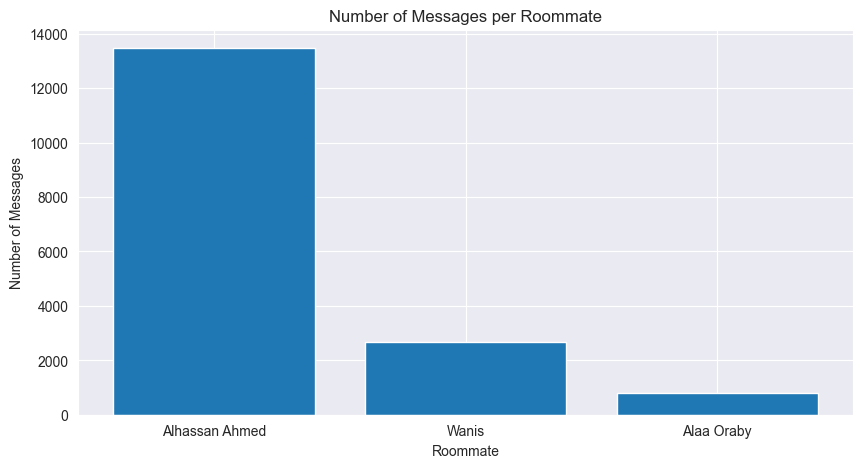

In [17]:
# Messages distribution
message_counts = chat_roommates['from_name'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(message_counts.keys(), message_counts.values)
plt.xlabel('Roommate')
plt.ylabel('Number of Messages')
plt.title('Number of Messages per Roommate')
plt.show()


### Vectorization 

In order to perform quantitative analysis on the text data, we first need to transform it into a numerical representation. We do so using the Term Frequency Inverse Document Frequency (TF-IDF) vectorizer. It basically counts the frequency of each word in one message and accounts for the frequency of the word across all messages to reduce the influence of highly common words (i.e. prepositions and connectors). In a more formal way, we say that 

$$tfidf(t, d) = tf(t, d) \times idf(t),$$
$$ = tf(t, d) \times \log{\frac{n}{df(t)}} + 1, $$ 

where $tf(t, d)$ is the proportion of the word $t$ relative to all words in document $d$, $n$ is the number of documents, and $df(t)$ is the number of documents that contain $t$. Multiplying by the inverse log ensures that we reduce the weight of terms occuring in many documnets, but the extra 1 in $idf(t)$ ensures that we do not output 0 for terms that appear in all documents. 

After vectorizing the texts, we print the first three messages and their vector form. The first message has two words, and its vector has two elements; the second messages has three words, and its vector has three elements, and so on. Furthemore, we print the words with the top 10 weights across all texts, and they are among the common words we use. The first three in English mean 'what', 'God', and 'but'.

In [18]:
# Vectorizing messages and their senders
chat_roommates['sender_numerice'] = pd.factorize(chat_roommates['from_name'])[0]
texts, senders = np.array(chat_roommates['text']), np.array(chat_roommates['sender_numerice'])

vectorizer = t.TfidfVectorizer()
vec_texts = vectorizer.fit_transform(texts)

print(f'Shape of vec_texts: {vec_texts.shape}')

Shape of vec_texts: (16947, 16827)


C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_17068\3352500311.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chat_roommates['sender_numerice'] = pd.factorize(chat_roommates['from_name'])[0]


In [19]:
print(f'First 3 texts: \n {texts[:3]} \n ')
print(f'First 3 senders and their codes: \n {chat_roommates[:3]["from_name"]}   {senders[:3]} ')
print(f'First 3 Vectors: \n {vec_texts[:3]}')

First 3 texts: 
 ['الحمدلله ياخويا' 'انت اخبارك اي' 'كل سنة و انت طيب'] 
 
First 3 senders and their codes: 
 171    Alhassan Ahmed
172    Alhassan Ahmed
173    Alhassan Ahmed
Name: from_name, dtype: object   [0 0 0] 
First 3 Vectors: 
   (0, 16178)	0.773802659124381
  (0, 5257)	0.6334267477238683
  (1, 6703)	0.3990743905841206
  (1, 3867)	0.7963583702116961
  (1, 6483)	0.4544809973735799
  (2, 10636)	0.5582922006189317
  (2, 10120)	0.6087606402775543
  (2, 12105)	0.4540882243042422
  (2, 6483)	0.3339523710428671


In [20]:
word_freq = np.asarray(vec_texts.sum(axis=0)).ravel()  # total weight per word
vocab = np.array(vectorizer.get_feature_names_out())

# sort and display top 10
top_indices = word_freq.argsort()[::-1][:10]
for word, freq in zip(vocab[top_indices], word_freq[top_indices]):
    print(f"{word}: {freq:.3f}")

اي: 347.127
الله: 260.203
بس: 221.863
في: 217.764
مش: 213.339
انت: 202.005
انا: 197.618
ان: 170.307
يب: 160.184
ولا: 159.615


## Analysis Discussion

For the next few sessions, I will be running classification models on the vectorized text messages. In particular, I want to classify the sender of the message into one of my three roommates using Naive Bayes classification. As mentioned earlier, the classes are imbalanced, so I try multiple approaches:
1. I train the model on the whole data set.
2. I train the model on the whole data, but I set the class prior to be uniform (1/3 for each class), so that the model does not outweigh the most prevelant class.
3. I randomly select a 1000 messages from each of my roommates and run the model on this smaller but balanced sample. 

Before running the model, I split the data into training and test sets with 80%-20% proportion to ensure that the model is evaluated and able to generalize to unseen data (the test set). 

In [21]:
# 80-20 train-test split for multi-class model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    vec_texts, senders, 
    test_size=0.2, 
    random_state=42, 
    stratify=senders
)

print(f'Multi-class train set: {X_train.shape[0]} samples')
print(f'Multi-class test set: {X_test.shape[0]} samples')
print(f'Train set class distribution: {np.bincount(y_train)}')
print(f'Test set class distribution: {np.bincount(y_test)}')


Multi-class train set: 13557 samples
Multi-class test set: 3390 samples
Train set class distribution: [10782  2133   642]
Test set class distribution: [2696  533  161]


## Model Selection and Explanation

Since we are doing a classification task, we might start with logistic regression. However, Naive Bayes is more ocmmon for text classification. We particularly use the Multinomial Naive Bayes, which calculates the maximum log likelihood for each word belonging to a class, and the resulting class is the one with the highest likelihood. More specifically, the algorithm calculates the following log-likelihood
$$\log{\frac{N_{yi}+ \alpha}{\sum_{i=1}^{n} N_{yi} + \alpha n}}, $$

where $N_{yi}$ is the number of times the word $i$ appears in the training set for class $y$. The $\alpha$ is a smoothing parameter to ensure that what is inside the log is not zero (in the case of a word not appearing in that class). We use the MultinomialNB class from Sklearn, which learns the prior probability from the data by default. 

=== MULTI-CLASS MODEL EVALUATION (TEST SET) ===
Test set size: 3390 samples


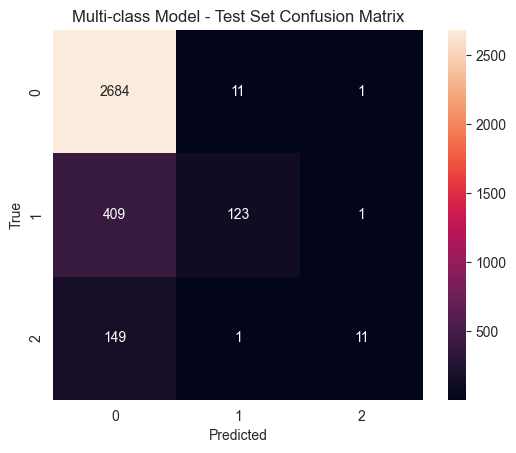

In [22]:
# Multi-class model training with train-test split
model = naive_bayes.MultinomialNB()
model.fit(X_train, y_train)
pred_senders = model.predict(X_test)

print("=== MULTI-CLASS MODEL EVALUATION (TEST SET) ===")
print(f"Test set size: {len(y_test)} samples")

confusion_mat = metrics.confusion_matrix(y_test, pred_senders)
sns.heatmap(confusion_mat, square=True, annot=True, fmt='d', )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Multi-class Model - Test Set Confusion Matrix')
plt.show()


## Further Predictions and Performance

In [23]:
# Calculate overall metrics on test set
def classification_metrics(y_test, pred, class_names):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='weighted')
    recall = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    print("=== MULTI-CLASS MODEL PERFORMANCE METRICS (TEST SET) ===")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    print("\n=== DETAILED CLASSIFICATION REPORT (TEST SET) ===")
    # Get the actual names for the classes
    print(classification_report(y_test, pred, target_names=class_names))

classification_metrics(y_test, pred_senders, class_names=roommates)

=== MULTI-CLASS MODEL PERFORMANCE METRICS (TEST SET) ===
Accuracy:  0.8313 (83.13%)
Precision: 0.8418
Recall:    0.8313
F1 Score:  0.7828

=== DETAILED CLASSIFICATION REPORT (TEST SET) ===
                precision    recall  f1-score   support

Alhassan Ahmed       0.83      1.00      0.90      2696
         Wanis       0.91      0.23      0.37       533
    Alaa Oraby       0.85      0.07      0.13       161

      accuracy                           0.83      3390
     macro avg       0.86      0.43      0.47      3390
  weighted avg       0.84      0.83      0.78      3390



As the results show, the model seems to have a pretty high overall accuracy, but the performance on classes 1 (Wanis) and 2 (Alaa Oraby) is very poor. For instance, the model only classifies 7% of Alaa's messages correctly and only 23% of Wanis's messages. In fact, if it is just predicting every message as being from Alhassan, the model's accuracy will be ~80%, which is just three points below the current accuracy. To mitigate that, we try a variant of the model where we set the prior probabilities to be uniform [1/3, 1/3, 1/3]. 

=== MULTI-CLASS MODEL EVALUATION (TEST SET) ===
Test set size: 3390 samples


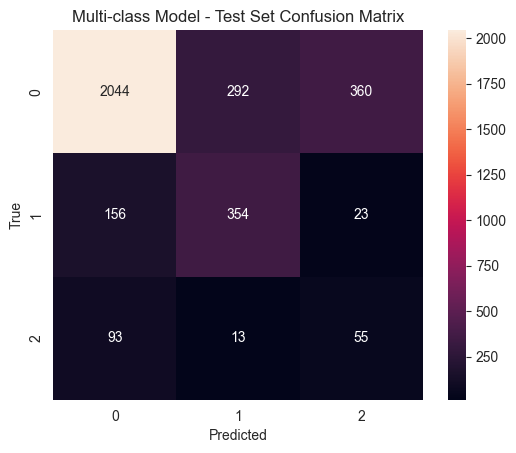

In [25]:
# MultinomialNB with uniform prior
model_uniform_prior = naive_bayes.MultinomialNB(class_prior=[1/3, 1/3, 1/3])
model_uniform_prior.fit(X_train, y_train)
pred_senders_uniform_prior = model_uniform_prior.predict(X_test)

print("=== MULTI-CLASS MODEL EVALUATION (TEST SET) ===")
print(f"Test set size: {len(y_test)} samples")

confusion_mat_uniform_prior = metrics.confusion_matrix(y_test, pred_senders_uniform_prior)
sns.heatmap(confusion_mat_uniform_prior, square=True, annot=True, fmt='d', )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Multi-class Model - Test Set Confusion Matrix')
plt.show()


In [41]:
classification_metrics(y_test, pred_senders_uniform_prior, class_names=roommates)

=== MULTI-CLASS MODEL PERFORMANCE METRICS (TEST SET) ===
Accuracy:  0.7236 (72.36%)
Precision: 0.7993
Recall:    0.7236
F1 Score:  0.7538

=== DETAILED CLASSIFICATION REPORT (TEST SET) ===
                precision    recall  f1-score   support

Alhassan Ahmed       0.89      0.76      0.82      2696
         Wanis       0.54      0.66      0.59       533
    Alaa Oraby       0.13      0.34      0.18       161

      accuracy                           0.72      3390
     macro avg       0.52      0.59      0.53      3390
  weighted avg       0.80      0.72      0.75      3390



By analyzing the new model's results, we see that the performance on Alhassan's messages drops a little bit, but there is a notable improvemenet for Wanis and Alaa since the recall went from 23% and 7% to 66% and 34%, respectively. 

We still try to improve the model further. To do so, we eliminate the class imbalance entirely by randomly sampling a subset of the messages from Alhassan and Wanis. After training the MultinomialNB on this subset of data, we set the accuracy (67%) dropped compared to the original model, but the confusion matrix tells that it is much better. It is able to classify 81% and 51% of Wanis's and Alaa's messages, respectively. 

## Sampling a uniform message distribution

In [26]:
## Sampling a uniform message distribution

# Create balanced dataset with 1000 samples from each class (0, 1, 2)
np.random.seed(42)  # For reproducibility

# Get indices for each class
class_0_indices = np.where(senders == 0)[0]  # Alhassan Ahmed
class_1_indices = np.where(senders == 1)[0]  # Wanis  
class_2_indices = np.where(senders == 2)[0]  # Alaa Oraby

print(f"Available samples per class:")
print(f"Class 0 (Alhassan Ahmed): {len(class_0_indices)} samples")
print(f"Class 1 (Wanis): {len(class_1_indices)} samples") 
print(f"Class 2 (Alaa Oraby): {len(class_2_indices)} samples")

# Sample 1000 from each class (or all available if less than 1000)
n_samples_per_class = 1000
sampled_indices = []

for class_indices in [class_0_indices, class_1_indices, class_2_indices]:
    if len(class_indices) >= n_samples_per_class:
        # Randomly sample 1000
        sampled = np.random.choice(class_indices, n_samples_per_class, replace=False)
    else:
        # Use all available samples
        sampled = class_indices
        print(f"Warning: Only {len(class_indices)} samples available, using all")
    
    sampled_indices.extend(sampled)

# Convert to numpy array and shuffle
sampled_indices = np.array(sampled_indices)
np.random.shuffle(sampled_indices)

# Create uniform arrays
senders_uniform = senders[sampled_indices]
vec_text_uniform = vec_texts[sampled_indices]

print(f"\nUniform sampling results:")
print(f"senders_uniform shape: {senders_uniform.shape}")
print(f"vec_text_uniform shape: {vec_text_uniform.shape}")
print(f"Class distribution in senders_uniform: {np.bincount(senders_uniform)}")
print(f"Total samples: {len(senders_uniform)}")


Available samples per class:
Class 0 (Alhassan Ahmed): 13478 samples
Class 1 (Wanis): 2666 samples
Class 2 (Alaa Oraby): 803 samples

Uniform sampling results:
senders_uniform shape: (2803,)
vec_text_uniform shape: (2803, 16827)
Class distribution in senders_uniform: [1000 1000  803]
Total samples: 2803


In [27]:
X_train_uniform, X_test_uniform, y_train_uniform, y_test_uniform = train_test_split(
    vec_text_uniform, senders_uniform, 
    test_size=0.2, 
    random_state=42, 
    stratify=senders_uniform
)

print(f'Uniform train set: {X_train_uniform.shape[0]} samples')
print(f'Uniform test set: {X_test_uniform.shape[0]} samples')
print(f'Uniform Train set class distribution: {np.bincount(y_train_uniform)}')
print(f'Uniform Test set class distribution: {np.bincount(y_test_uniform)}')

Uniform train set: 2242 samples
Uniform test set: 561 samples
Uniform Train set class distribution: [800 800 642]
Uniform Test set class distribution: [200 200 161]


=== MULTI-CLASS MODEL EVALUATION (TEST SET) ===
Test set size: 3390 samples


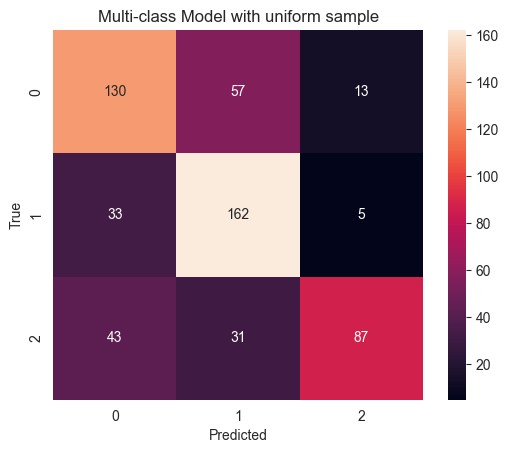

In [28]:
model_uniform_sample = naive_bayes.MultinomialNB()
model_uniform_sample.fit(X_train_uniform, y_train_uniform)
pred_senders_uniform_sample = model_uniform_sample.predict(X_test_uniform)

print("=== MULTI-CLASS MODEL EVALUATION (TEST SET) ===")
print(f"Test set size: {len(y_test)} samples")

confusion_mat_uniform_sample = metrics.confusion_matrix(y_test_uniform, pred_senders_uniform_sample)
sns.heatmap(confusion_mat_uniform_sample, square=True, annot=True, fmt='d', )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Multi-class Model with uniform sample')
plt.show()

In [29]:
classification_metrics(y_test_uniform, pred_senders_uniform_sample, roommates)

=== MULTI-CLASS MODEL PERFORMANCE METRICS (TEST SET) ===
Accuracy:  0.6756 (67.56%)
Precision: 0.6938
Recall:    0.6756
F1 Score:  0.6727

=== DETAILED CLASSIFICATION REPORT (TEST SET) ===
                precision    recall  f1-score   support

Alhassan Ahmed       0.63      0.65      0.64       200
         Wanis       0.65      0.81      0.72       200
    Alaa Oraby       0.83      0.54      0.65       161

      accuracy                           0.68       561
     macro avg       0.70      0.67      0.67       561
  weighted avg       0.69      0.68      0.67       561



## Complement Naive Bayes

Lastly, Sklearn has another class called ComplementNB that is specifically used for imbalanced classes. Instead of counting the word frequency in class $y$ as shown in the log-likelihood equation, it calculates the frequency in the complement of $y$. 

In terms of the overall accuracy, it is higher than the MultinomialNB trained on uniform data, but it still classifies a lot of Wanis's and Alaa's messages as being from Alhassan. However, it shows a significant improvement from the original MultinomialNB trained on all messages. 

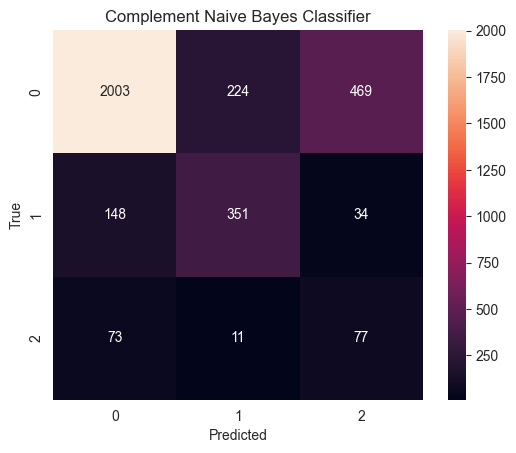

In [31]:
from sklearn.naive_bayes import ComplementNB

model_CNB = ComplementNB()
model_CNB.fit(X_train, y_train)
pred_senders_CNB = model_CNB.predict(X_test)

confusion_mat_CNB = metrics.confusion_matrix(y_test, pred_senders_CNB)
sns.heatmap(confusion_mat_CNB, square=True, annot=True, fmt='d', )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Complement Naive Bayes Classifier')
plt.show()

In [38]:
classification_metrics(y_test, pred_senders_CNB, roommates)

=== MULTI-CLASS MODEL PERFORMANCE METRICS (TEST SET) ===
Accuracy:  0.7133 (71.33%)
Precision: 0.7938
Recall:    0.7133
F1 Score:  0.7466

=== DETAILED CLASSIFICATION REPORT (TEST SET) ===
                precision    recall  f1-score   support

Alhassan Ahmed       0.87      0.76      0.81      2729
         Wanis       0.61      0.59      0.60       590
    Alaa Oraby       0.13      0.42      0.19       166

      accuracy                           0.71      3485
     macro avg       0.54      0.59      0.53      3485
  weighted avg       0.79      0.71      0.75      3485



### Naive Bayes from Scratch

We implement the MultinomialNB from scratch and apply to the sampled data (with uniform classes). The confusion matrix and the metrics show that it has the same performance as the Sklearn-based implementation, which indicates that the manual implemenatation is valid. 

In [ ]:
Lastly, Sklearn has another class called ComplementNB that is specifically used for imbalanced classes. Instead of counting the word frequency in class $y$ as shown in the log-likelihood equation, it calculates the frequency in the complement of $y$. 

In terms of the overall accuracy, it is higher than the MultinomialNB trained on uniform data, but it still classifies a lot of Wanis's and Alaa's messages as being from Alhassan. However, it shows a significant improvement from the original MultinomialNB trained on all messages. 

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_classes = len(self.classes) 
        n_features = X.shape[1] 

        # Count words per class
        self.class_count = np.zeros(n_classes)
        self.feature_count = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.class_count[idx] = X_c.shape[0]
            self.feature_count[idx, :] = X_c.sum(axis=0)

        # Compute priors and likelihoods (with smoothing)
        self.class_log_prior = np.log(self.class_count / self.class_count.sum())
        smoothed_fc = self.feature_count + self.alpha
        smoothed_cc = smoothed_fc.sum(axis=1).reshape(-1, 1)
        self.feature_log_prob = np.log(smoothed_fc / smoothed_cc)
    
    def predict(self, X):
        # matrix multiplication to multiply each message vector by the log likelihood
        log_probs = (X @ self.feature_log_prob.T) + self.class_log_prior
        return self.classes[np.argmax(log_probs, axis=1)]


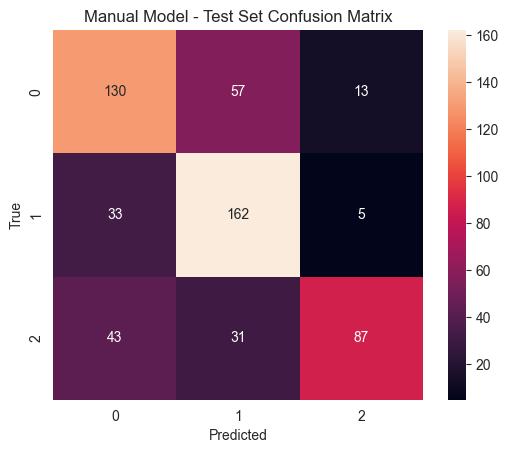

In [38]:
manual_model = MyMultinomialNB()
manual_model.fit(X_train_uniform, y_train_uniform)
pred_manual = manual_model.predict(X_test_uniform)

confusion_mat_manual = metrics.confusion_matrix(y_test_uniform, pred_manual)
sns.heatmap(confusion_mat_manual, square=True, annot=True, fmt='d', )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Manual Model - Test Set Confusion Matrix')
plt.show()

## Summary
I started with an idea that my roommates, while being from the same country and speak the same language, do have different personalities that are reflected on their communication. To analyze that, I trained a Multinomial Naive Bayes Classifier on Telegram messages from my three roommates. Initially, the model had a relatively high accuracy (~83%) but examining the confusion matrix showed that it was almost classifying all messages as being from Alhassan, who has a significantly higher number of messages. To account for the imbalance, I tried (i) setting a uniform prior (ii) training the model on a uniformly distributed subset of the messages and (iii) training a complement Naive Bayes classifier. All approaches showed some improvement over the original model, considering the precision and recall for Wanis and Alaa. Still, removing the data imbalance seemed to be the most effective way. 

I envision an extension to this work to be an analysis of the topics we talk about overall and per each one of the roommates, and I can include my own messages to this analysis. I would also like to divide the messages between 'academic year' and 'summer' to see if there is a significant difference in the topics we discuss. 

## References

scikit-learn. “1.9. Naive Bayes — Scikit-Learn 0.23.2 Documentation.” Scikit-Learn.org, 2024, scikit-learn.org/stable/modules/naive_bayes.html#multinomial-naive-bayes.

scikit-learn. “Sklearn.feature_extraction.text.TfidfTransformer — Scikit-Learn 0.23.1 Documentation.” Scikit-Learn.org, 2025, scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html.

# Appendix

## Model Before Removing Emojis and Links

I initially trained the model before cleaning the messages from emojis and links, which had slightly lower performance compared to the current one trained on the full data. 

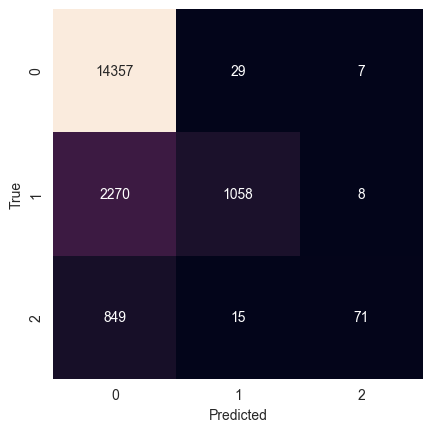

In [ ]:
model = naive_bayes.MultinomialNB()
model.fit(vec_texts, senders)
pred_senders = model.predict(vec_texts)

confusion_mat = metrics.confusion_matrix(senders, pred_senders)
sns.heatmap(confusion_mat, square=True, annot=True, fmt='d', )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Message Themes

I thought about analyzing themes/topics my roommates talk about with me because I had a hypothesis that we mostly talk about academics. Since there are no defined themes in the data, I ran unsupervised KMeans clustering, which creates k (3) clusters and picks features that are closest to the center of that cluster. I visualized the result after doing a Principal Component Analysis (PCA) to reduce the dimensionality of the data to 2 dimensions. I saw that the clusters seem to map to the senders without really showing "clustering" that I could map to themes. I think I can build on this by dividing the messages into smaller tokens and running the analysis on the token level rather the message level, since it is more reasonable to map academic-related words. 

In [44]:
## K-means Clustering and PCA Visualization

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare the training data for clustering
print("=== K-MEANS CLUSTERING ANALYSIS ===")
print(f"Training data shape: {X_train.shape}")

# Apply K-means clustering with 3 clusters (matching the 3 classes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train)

print(f"K-means clustering completed")
print(f"Cluster distribution: {np.bincount(cluster_labels)}")

# Compare clusters with actual labels
print(f"\nActual class distribution: {np.bincount(y_train)}")
print(f"Cluster vs Class comparison:")
for i in range(3):
    cluster_mask = cluster_labels == i
    actual_classes = y_train[cluster_mask]
    print(f"Cluster {i}: {len(actual_classes)} samples")
    print(f"  Class distribution: {np.bincount(actual_classes, minlength=3)}")
    print()


=== K-MEANS CLUSTERING ANALYSIS ===
Training data shape: (13936, 16827)
K-means clustering completed
Cluster distribution: [13279   145   512]

Actual class distribution: [10912  2358   666]
Cluster vs Class comparison:
Cluster 0: 13279 samples
  Class distribution: [10599  2102   578]

Cluster 1: 145 samples
  Class distribution: [64 74  7]

Cluster 2: 512 samples
  Class distribution: [249 182  81]



=== PCA DIMENSIONALITY REDUCTION ===
Dense training data shape: (13936, 16827)
PCA explained variance ratio: [0.01129255 0.00913853]
Total variance explained: 0.020


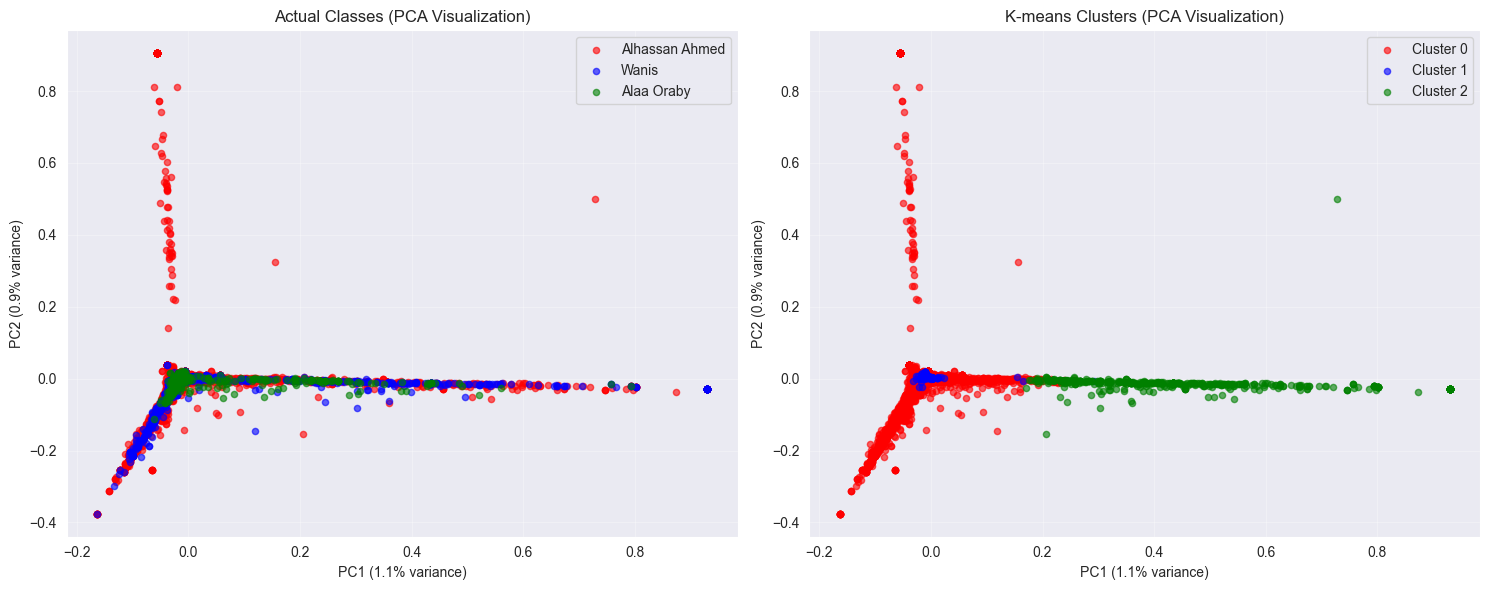

In [46]:
# Apply PCA for dimensionality reduction and visualization
print("=== PCA DIMENSIONALITY REDUCTION ===")

# Convert sparse matrix to dense for PCA (if needed)
if hasattr(X_train, 'toarray'):
    X_train_dense = X_train.toarray()
else:
    X_train_dense = X_train

print(f"Dense training data shape: {X_train_dense.shape}")

# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_dense)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual classes
class_names = ['Alhassan Ahmed', 'Wanis', 'Alaa Oraby']
colors = ['red', 'blue', 'green']
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = y_train == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name, alpha=0.6, s=20)

ax1.set_title('Actual Classes (PCA Visualization)')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: K-means clusters
cluster_colors = ['red', 'blue', 'green']
for i, color in enumerate(cluster_colors):
    mask = cluster_labels == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=f'Cluster {i}', alpha=0.6, s=20)

ax2.set_title('K-means Clusters (PCA Visualization)')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
